The final project asks you to analyze and assess the statistical significance of events in scientific data relative to a model. You will do this by following tutorials developed for a nearly identical problem, so that your main task will be to carefully read through these tutorials, copy the parts that you need and modify some code to customize it for your own project.

You will create a Jupyter notebook for this project and, when finished, you will upload your notebook to GitHub and submit the URL to it as the submission to the assignment.

Before you begin
Create a new notebook in your working directory. Copy these instructions as plain text into the first cell. That way you will not have to flip back and forth between your notebook and this page.
Make sure that the astropy and sep packages are installed on your machine by launching a command window and running:
pip install astropy
pip install sep
Download the file hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits from this archive Links to an external site. and save it to your working directory (the same directory that has your notebook).
The task
Follow the tutorial found at https://sep.readthedocs.io/en/stable/tutorial.html Links to an external site., applying it to the data file you just downloaded. For best results (and for full credit) follow these suggestions: 

Gradually copy the code from the tutorial into your own jupyter notebook, run and debug until you successfully replicate the tutorial. Do not try to copy and run it all at once, it's not going to work! You need to debug as you go.
Use markdown to break the notebook into sections, as in the tutorial.
Finish your notebook by answering the following questions, using a combination of text and code directly in the notebook. (Terms like sources and fluxes will gradually become clear as you progress through the tutorial. You are not expected to fully understand all the details.) 
1) How many sources (stars) do you find in the data? Histogram their fluxes.
2) What are the mean, median, and standard deviation of the distribution of fluxes.
3) What is the largest outlier in the distribution; how many standard deviations is it away from the mean?

In [18]:
import numpy as np
import sep

import matplotlib.pyplot as plt
from matplotlib import rcParams

import fitsio

%matplotlib inline

rcParams['figure.figsize'] = [10.,8.]

In [19]:
data = fitsio.read("hlsp_hudf12_hst_wfc3ir_udfmain_f105w_v1.0_drz.fits")

In [20]:
data = data.astype(data.dtype.newbyteorder("="))

In [21]:
print(data.shape)

(3600, 3600)


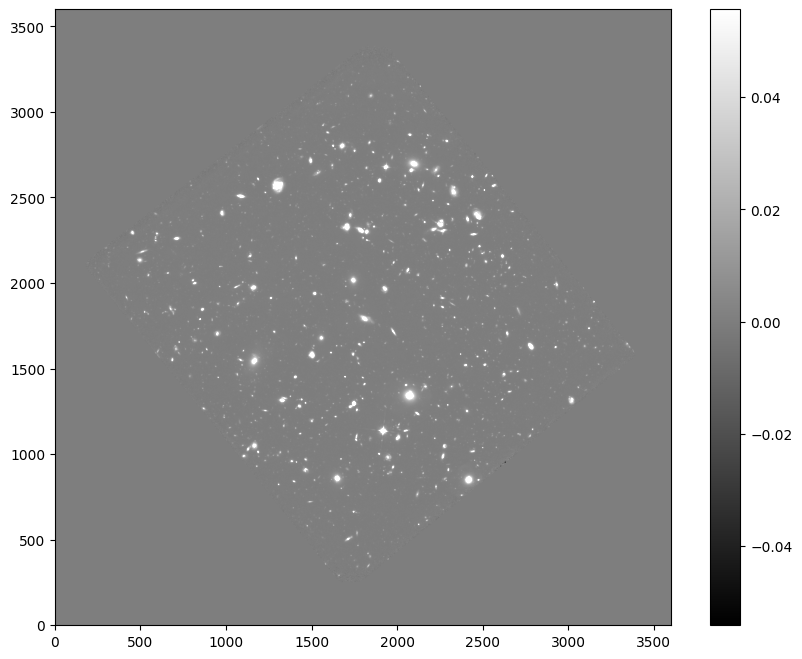

In [22]:
m, s = np.mean(data), np.std(data)

plt.imshow(data, cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar()

In [23]:
bkg = sep.Background(data)

In [24]:
print("Global background:", bkg.globalback)
print("Global RMS noise:", bkg.globalrms)

Global background: 0.0
Global RMS noise: 0.0005398219218477607


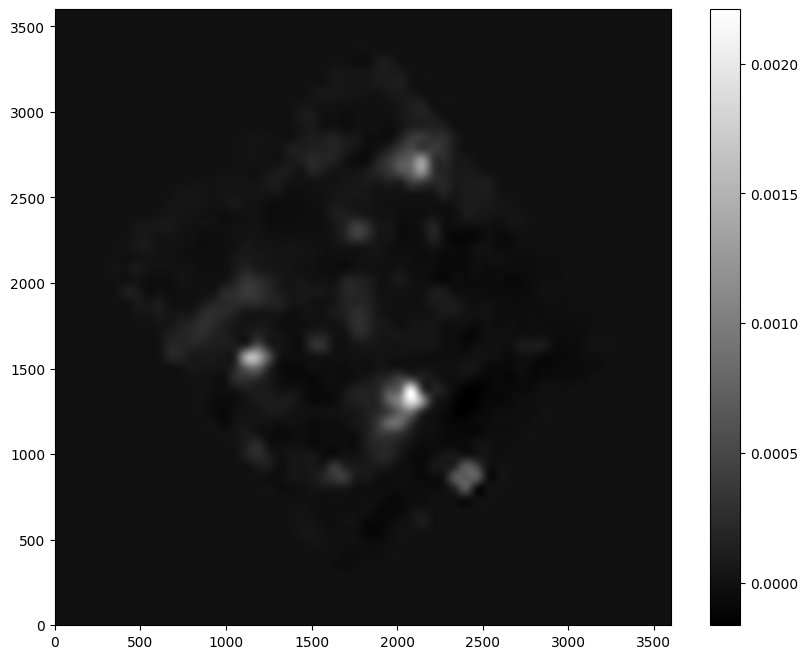

In [25]:
bkg_image = bkg.back()

plt.imshow(bkg_image, cmap='gray', origin='lower')
plt.colorbar()

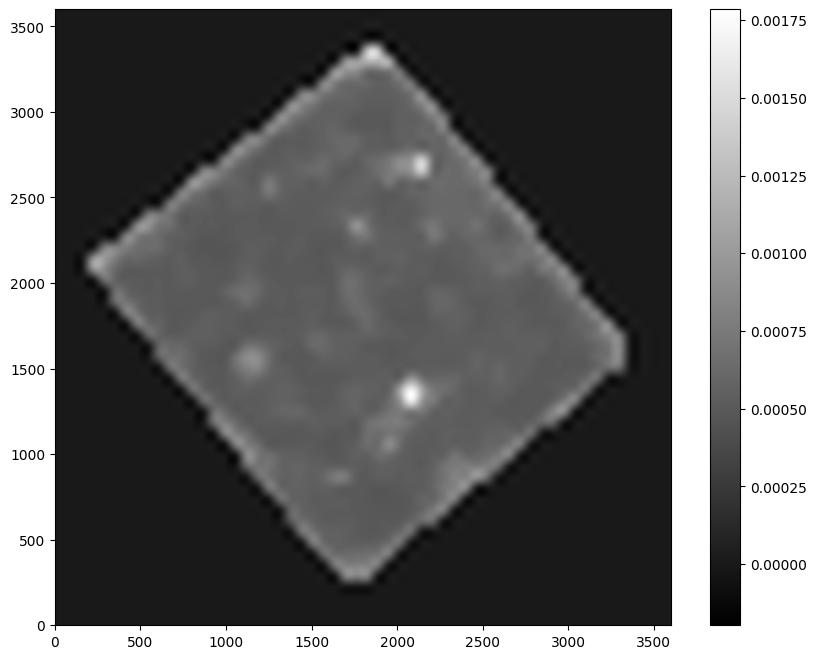

In [26]:
bkg_rms = bkg.rms()

plt.imshow(bkg_rms, cmap='gray', origin='lower')
plt.colorbar()

In [27]:
data_sub = data - bkg

In [39]:
objects = sep.extract(data_sub, 30.0, err=bkg.globalrms)

print("Number of detected sources:", len(objects))

Number of detected sources: 694


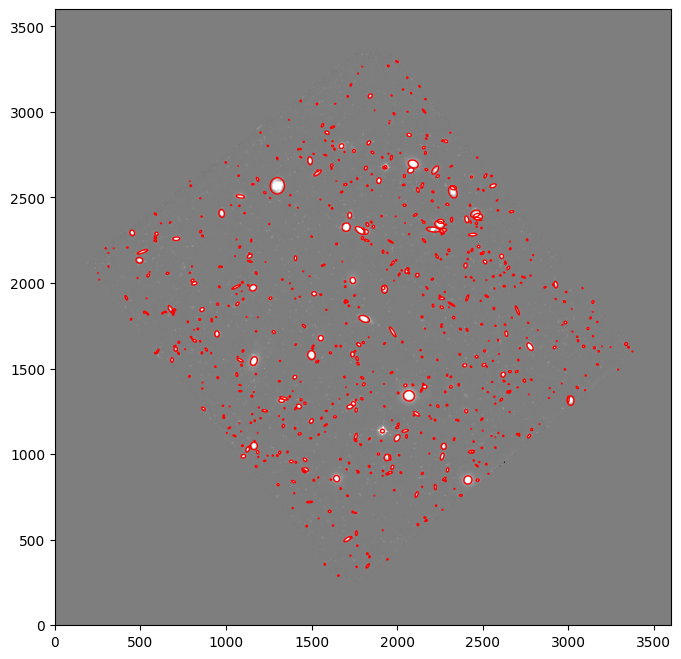

In [40]:
from matplotlib.patches import Ellipse

fig, ax = plt.subplots()

m, s = np.mean(data_sub), np.std(data_sub)

ax.imshow(data_sub, cmap='gray', vmin=m-s, vmax=m+s, origin='lower')

for i in range(len(objects)):
    e = Ellipse(
        xy=(objects['x'][i], objects['y'][i]),
        width=6*objects['a'][i],
        height=6*objects['b'][i],
        angle=objects['theta'][i]*180/np.pi
    )
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

In [41]:
flux, fluxerr, flag = sep.sum_circle(
    data_sub,
    objects['x'],
    objects['y'],
    3.0,
    err=bkg.globalrms,
    gain=1.0
)

In [42]:
for i in range(10):
    print(f"object {i}: flux = {flux[i]} +/- {fluxerr[i]}")

object 0: flux = 1.152732253037393 +/- 1.0736575419377485
object 1: flux = 0.5545335014909507 +/- 0.7446755954781584
object 2: flux = 1.122580334916711 +/- 1.0595228002597217
object 3: flux = 0.8754771635419094 +/- 0.9356737516799242
object 4: flux = 0.687015568986826 +/- 0.8288690085346667
object 5: flux = 0.7626077935099603 +/- 0.8732789118216331
object 6: flux = 0.49643886208534244 +/- 0.7045900082903003
object 7: flux = 1.254951081909239 +/- 1.1202496803086597
object 8: flux = 0.9731712881103158 +/- 0.9864986268497402
object 9: flux = 3.2113090333342558 +/- 1.7920148676839607


Number of sources detected: 694


Text(0.5, 1.0, 'Histogram of Source Fluxes')

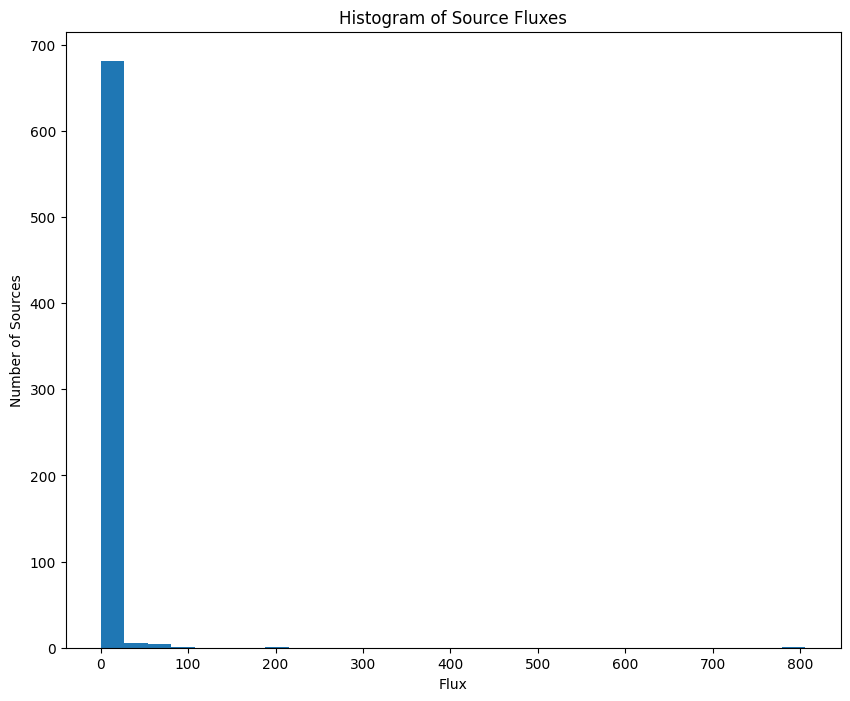

In [43]:
num_sources = len(flux)
print("Number of sources detected:", num_sources)

plt.hist(flux, bins=30)
plt.xlabel("Flux")
plt.ylabel("Number of Sources")
plt.title("Histogram of Source Fluxes")

In [44]:
mean_flux = np.mean(flux)
median_flux = np.median(flux)
std_flux = np.std(flux)

print("Mean flux:", mean_flux)
print("Median flux:", median_flux)
print("Standard deviation:", std_flux)

Mean flux: 4.002130043266595
Median flux: 0.8949735747277738
Standard deviation: 32.34797702331965


In [45]:
z_scores = np.abs((flux - mean_flux) / std_flux)

max_outlier_index = np.argmax(z_scores)

largest_outlier_flux = flux[max_outlier_index]
largest_outlier_sigma = z_scores[max_outlier_index]

print("Largest outlier flux:", largest_outlier_flux)
print("Distance from mean (in sigma):", largest_outlier_sigma)

Largest outlier flux: 805.910366077423
Distance from mean (in sigma): 24.790058291931544
